In [2]:
import pandas as pd

In [79]:
# 1. Load Data
file_path = '../data/processed/dataset_final.csv'

df = pd.read_csv(file_path)

In [80]:
df

,transaction_type_online purchase,transaction_type_transfer,transaction_type_withdrawal,merchant_category_Clothing,merchant_category_Crypto,merchant_category_Electronics,merchant_category_Entertainment,merchant_category_Food,merchant_category_Gambling,merchant_category_Services,...,account_age_days,description_risk_score,transaction_frequency_24h,num_failed_transactions_7d,transaction_hour,is_weekend,num_devices_used,num_countries_used,kyc_verified,is_fraud
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,-0.929790,-0.368841,0.000000,0.000000,8.000000,0.000000,2.000000,0.000000,0.000000,0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.761706,-0.368841,0.000000,0.000000,7.000000,0.000000,2.000000,0.000000,1.000000,0
2,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-1.964482,-0.368841,0.000000,0.000000,19.000000,0.000000,1.000000,0.000000,0.000000,1
3,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,-0.560900,3.310755,0.000000,0.000000,3.000000,0.000000,1.000000,1.000000,1.000000,1
4,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-1.064750,-0.368841,0.000000,0.000000,10.000000,0.000000,2.000000,0.000000,0.000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,-0.203948,-0.750026,1.910238,-1.254917,17.590397,1.515989,1.451670,-0.632398,2.499171,0
1196,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.703249,-0.775283,-0.428285,0.797061,8.393788,0.931623,0.287628,-0.664923,0.176913,0
1197,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,-1.015343,3.217018,-0.875200,0.716758,2.408601,2.285924,2.401097,0.323237,1.236132,1
1198,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,-1.476658,-0.078490,-0.208216,-0.946535,17.659267,0.274012,2.283382,-0.844388,0.658808,0


In [81]:
print(df.columns.tolist())

['transaction_type_online purchase', 'transaction_type_transfer', 'transaction_type_withdrawal', 'merchant_category_Clothing', 'merchant_category_Crypto', 'merchant_category_Electronics', 'merchant_category_Entertainment', 'merchant_category_Food', 'merchant_category_Gambling', 'merchant_category_Services', 'merchant_category_Travel', 'merchant_category_Utilities', 'device_type_desktop', 'device_type_mobile', 'device_type_tablet', 'payment_channel_bank', 'payment_channel_card', 'payment_channel_e-wallet', 'description_tone_panic', 'description_tone_routine', 'description_tone_urgent', 'semantic_merchant_category_crypto/finance', 'semantic_merchant_category_daily essentials', 'semantic_merchant_category_luxury goods', 'semantic_merchant_category_other', 'semantic_merchant_category_services', 'transaction_amount', 'account_balance_before', 'account_balance_after', 'avg_transaction_amount_7d', 'time_since_last_transaction_hr', 'account_age_days', 'description_risk_score', 'transaction_fre

In [82]:
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report
)

from xgboost import XGBClassifier

In [83]:
X = df.drop(columns=["is_fraud"])
y = df["is_fraud"]

print(X.shape, y.shape)

(1200, 40) (1200,)


In [85]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)


Train: (960, 40)
Test : (240, 40)


In [86]:
baseline_model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

baseline_model.fit(X_train, y_train)


y_pred = baseline_model.predict(X_test)
y_proba = baseline_model.predict_proba(X_test)[:, 1]



accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print("Baseline XGBoost Results")
print("-------------------------")
print(f"Accuracy : {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall   : {recall:.3f}")
print(f"F1-score : {f1:.3f}")
print(f"ROC-AUC  : {roc_auc:.3f}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Baseline XGBoost Results
-------------------------
Accuracy : 0.833
Precision: 0.773
Recall   : 0.327
F1-score : 0.459
ROC-AUC  : 0.630

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.97      0.90       188
           1       0.77      0.33      0.46        52

    accuracy                           0.83       240
   macro avg       0.81      0.65      0.68       240
weighted avg       0.82      0.83      0.81       240



In [87]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "n_estimators": [200,300,400,600,700,800,900,1000],
    "max_depth": [1,2,3, 4, 5, 6],
    "learning_rate": [0.01,0.025, 0.05,0.075, 0.1],
    "subsample": [0.3,0.4,0.5,0.6,0.7, 0.8, 0.9],
    "colsample_bytree": [0.3,0.4,0.5,0.6,0.7, 0.8, 0.9],
    "gamma": [0, 0.1, 0.3],
    "min_child_weight": [1, 3, 5]
}


xgb_tuned = XGBClassifier(
    eval_metric="logloss",
    random_state=42
)

random_search = RandomizedSearchCV(
    estimator=xgb_tuned,
    param_distributions=param_dist,
    n_iter=100,                
    scoring="accuracy",              
    cv=7,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)

print("Best Parameters:")
print(random_search.best_params_)


Fitting 7 folds for each of 100 candidates, totalling 700 fits
Best Parameters:
{'subsample': 0.4, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.025, 'gamma': 0.3, 'colsample_bytree': 0.7}


In [88]:
best_model = random_search.best_estimator_

y_pred_tuned = best_model.predict(X_test)
y_proba_tuned = best_model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred_tuned)
precision = precision_score(y_test, y_pred_tuned)
recall = recall_score(y_test, y_pred_tuned)
f1 = f1_score(y_test, y_pred_tuned)
roc_auc = roc_auc_score(y_test, y_proba_tuned)

print("Fine-Tuned XGBoost Results")
print("---------------------------")
print(f"Accuracy : {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall   : {recall:.3f}")
print(f"F1-score : {f1:.3f}")
print(f"ROC-AUC  : {roc_auc:.3f}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_tuned))


Fine-Tuned XGBoost Results
---------------------------
Accuracy : 0.846
Precision: 0.895
Recall   : 0.327
F1-score : 0.479
ROC-AUC  : 0.673

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.99      0.91       188
           1       0.89      0.33      0.48        52

    accuracy                           0.85       240
   macro avg       0.87      0.66      0.69       240
weighted avg       0.85      0.85      0.82       240



In [89]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# Use your BEST fine-tuned model so far
best_model.fit(X_train, y_train)

# Predict probabilities
y_proba = best_model.predict_proba(X_test)[:, 1]

# Search for best threshold
thresholds = np.arange(0.1, 0.9, 0.01)
best_acc = 0
best_thresh = 0

for t in thresholds:
    y_pred_thresh = (y_proba >= t).astype(int)
    acc = accuracy_score(y_test, y_pred_thresh)

    if acc > best_acc:
        best_acc = acc
        best_thresh = t

print("Best Threshold:", round(best_thresh, 2))
print("Best Accuracy:", round(best_acc, 3))

# Final evaluation with best threshold
y_final = (y_proba >= best_thresh).astype(int)

print("\nClassification Report (Threshold Tuned):\n")
print(classification_report(y_test, y_final))

print("ROC-AUC:", roc_auc_score(y_test, y_proba))


Best Threshold: 0.67
Best Accuracy: 0.854

Classification Report (Threshold Tuned):

              precision    recall  f1-score   support

           0       0.84      1.00      0.91       188
           1       1.00      0.33      0.49        52

    accuracy                           0.85       240
   macro avg       0.92      0.66      0.70       240
weighted avg       0.88      0.85      0.82       240

ROC-AUC: 0.6728723404255319


In [90]:
from sklearn.metrics import confusion_matrix
import pandas as pd

# ===============================
# E. Confusion Matrix
# ===============================
cm = confusion_matrix(y_test, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=["Actual Non-Fraud (0)", "Actual Fraud (1)"],
    columns=["Predicted Non-Fraud (0)", "Predicted Fraud (1)"]
)

print("\nConfusion Matrix:")
print(cm_df)


Confusion Matrix:
                      Predicted Non-Fraud (0)  Predicted Fraud (1)
Actual Non-Fraud (0)                      183                    5
Actual Fraud (1)                           35                   17


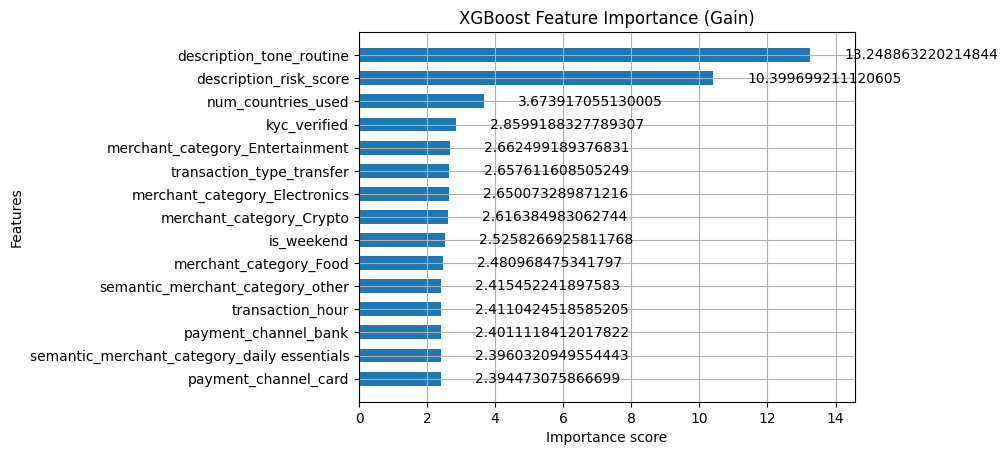

In [95]:
xgb.plot_importance(
    best_model,
    importance_type="gain",
    max_num_features=15,
    height=0.6
)
plt.title("XGBoost Feature Importance (Gain)")
plt.show()


In [92]:
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)

# ===============================
# CONFIG
# ===============================
threshold = 0.67
n_splits = 5

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

acc_scores = []
prec_scores = []
rec_scores = []
f1_scores = []
auc_scores = []

# ===============================
# CROSS-VALIDATION LOOP
# ===============================
for train_idx, val_idx in skf.split(X_train, y_train):
    X_tr = X_train.iloc[train_idx]
    X_val = X_train.iloc[val_idx]
    y_tr = y_train.iloc[train_idx]
    y_val = y_train.iloc[val_idx]

    # Train model on fold
    best_model.fit(X_tr, y_tr)

    # Predict probabilities
    y_val_proba = best_model.predict_proba(X_val)[:, 1]

    # Apply threshold
    y_val_pred = (y_val_proba >= threshold).astype(int)

    # Metrics
    acc_scores.append(accuracy_score(y_val, y_val_pred))
    prec_scores.append(precision_score(y_val, y_val_pred, zero_division=0))
    rec_scores.append(recall_score(y_val, y_val_pred))
    f1_scores.append(f1_score(y_val, y_val_pred))
    auc_scores.append(roc_auc_score(y_val, y_val_proba))

# ===============================
# RESULTS
# ===============================
print("\nCross-Validation Results (Threshold = 0.67)")
print("-------------------------------------------")
print(f"ACCURACY  : {np.mean(acc_scores):.3f} ± {np.std(acc_scores):.3f}")
print(f"PRECISION : {np.mean(prec_scores):.3f} ± {np.std(prec_scores):.3f}")
print(f"RECALL    : {np.mean(rec_scores):.3f} ± {np.std(rec_scores):.3f}")
print(f"F1        : {np.mean(f1_scores):.3f} ± {np.std(f1_scores):.3f}")
print(f"ROC-AUC   : {np.mean(auc_scores):.3f} ± {np.std(auc_scores):.3f}")



Cross-Validation Results (Threshold = 0.67)
-------------------------------------------
ACCURACY  : 0.867 ± 0.016
PRECISION : 1.000 ± 0.000
RECALL    : 0.387 ± 0.077
F1        : 0.554 ± 0.081
ROC-AUC   : 0.731 ± 0.035
